In [1]:
import pandas as pd
import numpy as np

from prophet import Prophet

from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error

import plotly.graph_objs as go
import plotly.offline as py

from pathlib import Path
import os
from dotenv import load_dotenv
import hopsworks

In [2]:
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

In [3]:
load_dotenv(PROJECT_ROOT / ".env")

key = os.getenv("HOPSWORK_KEY")

In [4]:
project = hopsworks.login(
    project='aqi_karachi_samu_2026',
    host="eu-west.cloud.hopsworks.ai",
    port=443,
    api_key_value=key,
)

fs = project.get_feature_store()
print(f"Connected to {project.name}")

2026-08-27 01:19:36,604 INFO: Initializing external client
2026-08-27 01:19:36,605 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-27 01:19:40,578 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41193
Connected to aqi_karachi_samu_2026


In [5]:
target = "day_1_future_aqi"
day_1_fv = fs.get_feature_view(name="view_aqi_day1", version=1)

In [6]:
x, y = day_1_fv.training_data()

Reading data from Hopsworks, using Hopsworks Feature Query Service.     

2026-08-27 01:19:53,281 INFO: Computing insert statistics


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.17s) 


In [7]:
day1 = x.copy()
day1[target] = y[target]

In [8]:
day1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time                       1092 non-null   object 
 1   temperature_2m             1092 non-null   float64
 2   wind_speed_10m             1092 non-null   float64
 3   relative_humidity_2m       1092 non-null   float64
 4   surface_pressure           1092 non-null   float64
 5   boundary_layer_height      911 non-null    float64
 6   dew_point_2m               1092 non-null   float64
 7   precipitation              1092 non-null   float64
 8   cloud_cover                1092 non-null   float64
 9   wind_direction_10m         1092 non-null   float64
 10  wind_gusts_10m             1092 non-null   float64
 11  shortwave_radiation        1092 non-null   float64
 12  pm10                       1092 non-null   float64
 13  pm2_5                      1092 non-null   float

In [9]:
day1.time = pd.to_datetime(day1.time)

In [10]:
day1 = day1.sort_values("time").reset_index(drop=True)

In [11]:
day1 = day1.drop(columns = ["boundary_layer_height", "f24_boundary_layer_height", "wind_pollution_dispersion"])

In [12]:
day1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   time                      1092 non-null   datetime64[ns, UTC]
 1   temperature_2m            1092 non-null   float64            
 2   wind_speed_10m            1092 non-null   float64            
 3   relative_humidity_2m      1092 non-null   float64            
 4   surface_pressure          1092 non-null   float64            
 5   dew_point_2m              1092 non-null   float64            
 6   precipitation             1092 non-null   float64            
 7   cloud_cover               1092 non-null   float64            
 8   wind_direction_10m        1092 non-null   float64            
 9   wind_gusts_10m            1092 non-null   float64            
 10  shortwave_radiation       1092 non-null   float64            
 11  pm10             

# Train and Test Split

In [13]:
Train = day1.iloc[:873,:]

In [14]:
Test = day1.iloc[873:,:]

In [15]:
Train.shape

(873, 47)

In [16]:
Test.shape

(219, 47)

In [17]:
Train.head()

,time,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_relative_humidity_2m,f24_surface_pressure,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,pressure_change_3hour,humidity_level,day_1_future_aqi
0,2023-08-04 00:00:00+00:00,28.441667,20.516667,83.458333,1000.087500,25.291667,0.037500,50.083333,245.083333,31.941667,...,81.750000,1002.600000,24.866667,0.037500,69.833333,33.450000,220.291667,0.225000,3.150000,79.458333
1,2023-08-05 00:00:00+00:00,28.329167,21.941667,81.750000,1002.600000,24.866667,0.037500,69.833333,247.750000,33.450000,...,80.375000,1001.608333,24.479167,0.029167,81.625000,45.562500,175.958333,0.266667,3.462500,78.833333
2,2023-08-06 00:00:00+00:00,28.233333,30.679167,80.375000,1001.608333,24.479167,0.029167,81.625000,254.500000,45.562500,...,80.208333,998.991667,24.266667,0.070833,75.000000,49.770833,171.375000,-0.387500,3.754167,78.875000
3,2023-08-07 00:00:00+00:00,28.041667,33.220833,80.208333,998.991667,24.266667,0.070833,75.000000,250.250000,49.770833,...,81.666667,999.362500,24.512500,0.091667,68.541667,44.275000,172.000000,-0.200000,3.775000,78.791667
4,2023-08-08 00:00:00+00:00,27.995833,29.429167,81.666667,999.362500,24.512500,0.091667,68.541667,245.916667,44.275000,...,81.625000,1002.587500,24.487500,0.033333,72.916667,43.120833,220.875000,0.304167,3.483333,73.416667


In [18]:
Test.head()

,time,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f24_relative_humidity_2m,f24_surface_pressure,f24_dew_point_2m,f24_precipitation,f24_cloud_cover,f24_wind_gusts_10m,f24_shortwave_radiation,pressure_change_3hour,humidity_level,day_1_future_aqi
873,2025-12-24 00:00:00+00:00,20.666667,7.579167,46.458333,1015.737500,7.979167,0.0,10.666667,139.666667,18.550000,...,56.666667,1014.941667,10.575000,0.0,81.750000,15.454167,161.000000,-0.212500,12.687500,121.041667
874,2025-12-25 00:00:00+00:00,19.608333,6.100000,56.666667,1014.941667,10.575000,0.0,81.750000,187.833333,15.454167,...,67.250000,1014.783333,12.845833,0.0,20.458333,14.829167,170.375000,0.045833,9.033333,113.125000
875,2025-12-26 00:00:00+00:00,19.729167,5.962500,67.250000,1014.783333,12.845833,0.0,20.458333,172.958333,14.829167,...,49.208333,1015.150000,8.495833,0.0,5.333333,17.029167,171.416667,-0.054167,6.883333,122.375000
876,2025-12-27 00:00:00+00:00,20.204167,7.041667,49.208333,1015.150000,8.495833,0.0,5.333333,109.583333,17.029167,...,42.541667,1015.270833,6.675000,0.0,23.125000,16.187500,167.041667,0.041667,11.708333,121.666667
877,2025-12-28 00:00:00+00:00,20.337500,6.658333,42.541667,1015.270833,6.675000,0.0,23.125000,130.250000,16.187500,...,47.916667,1014.804167,8.458333,0.0,0.000000,16.629167,171.500000,-0.020833,13.662500,128.458333


# Renaming the columns to ds and y

In [19]:
Train = Train.rename(columns = {'day_1_future_aqi':'y', 'time':'ds'})
Test = Test.rename(columns = {'day_1_future_aqi':'y', 'time':'ds'})

In [20]:
Train["ds"] = Train["ds"].dt.tz_localize(None)
Test["ds"]  = Test["ds"].dt.tz_localize(None)

# Saving The Copy

In [21]:
Train['y_orig'] = Train['y']
Test['y_orig'] = Test['y']

# Log Transformation

In [22]:
Train['y'] = np.log(Train['y'])
Test['y'] = np.log(Test['y'])

# Model Build

In [23]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.add_regressor("rolled_mean_aqi_24hr")
model.add_regressor("f24_wind_speed_10m")
model.add_regressor("f24_dew_point_2m")
model.fit(Train)

2026-08-27 01:19:55,168 INFO: Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2026-08-27 01:19:55,203 INFO: Chain [1] start processing
2026-08-27 01:19:57,547 INFO: Chain [1] done processing


# For Plotting Training and Testing Data

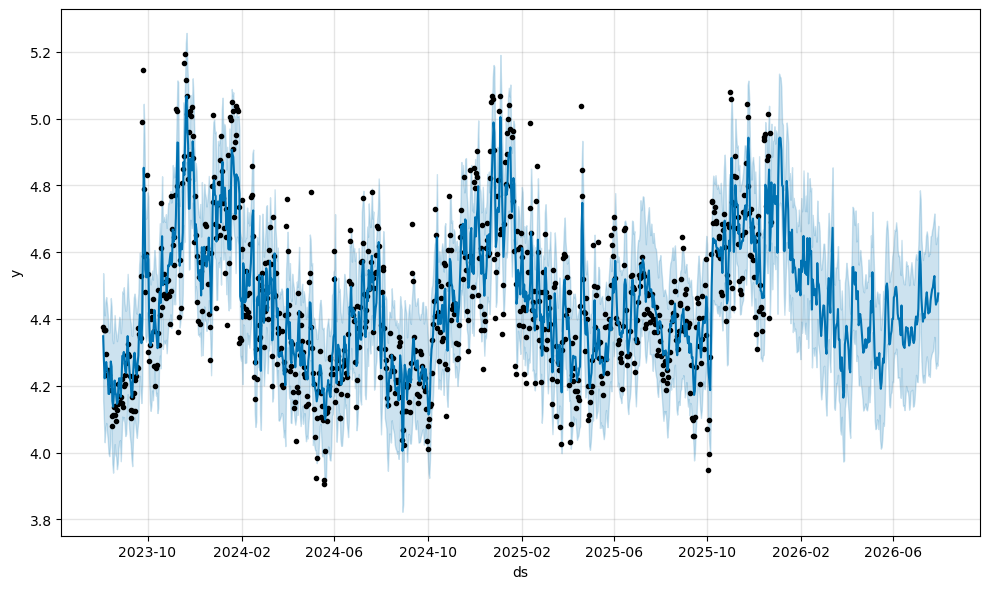

In [24]:
future_Data_Plot = pd.concat([Train, Test], ignore_index = True)
future_Data_Plot_Predict = model.predict(future_Data_Plot)
model.plot(future_Data_Plot_Predict);

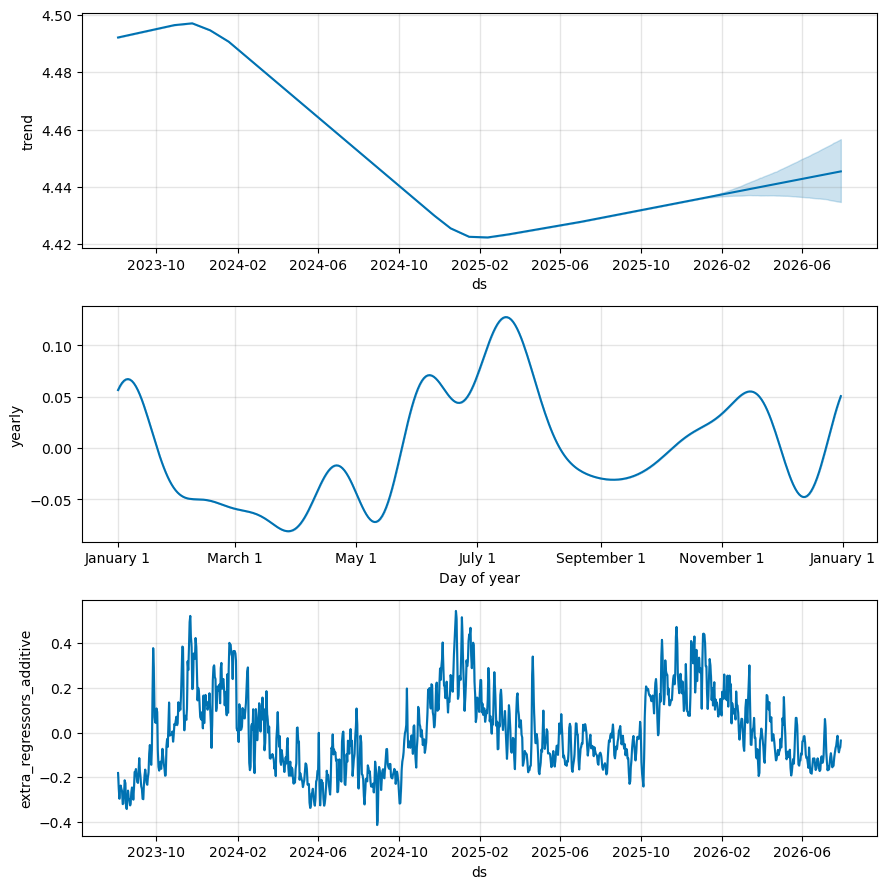

In [25]:
model.plot_components(future_Data_Plot_Predict);

# Now Check the Plot with Without Regressor

In [26]:
model_simple = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model_simple.fit(Train)

2026-08-27 01:19:58,960 INFO: Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2026-08-27 01:19:59,000 INFO: Chain [1] start processing
2026-08-27 01:19:59,056 INFO: Chain [1] done processing


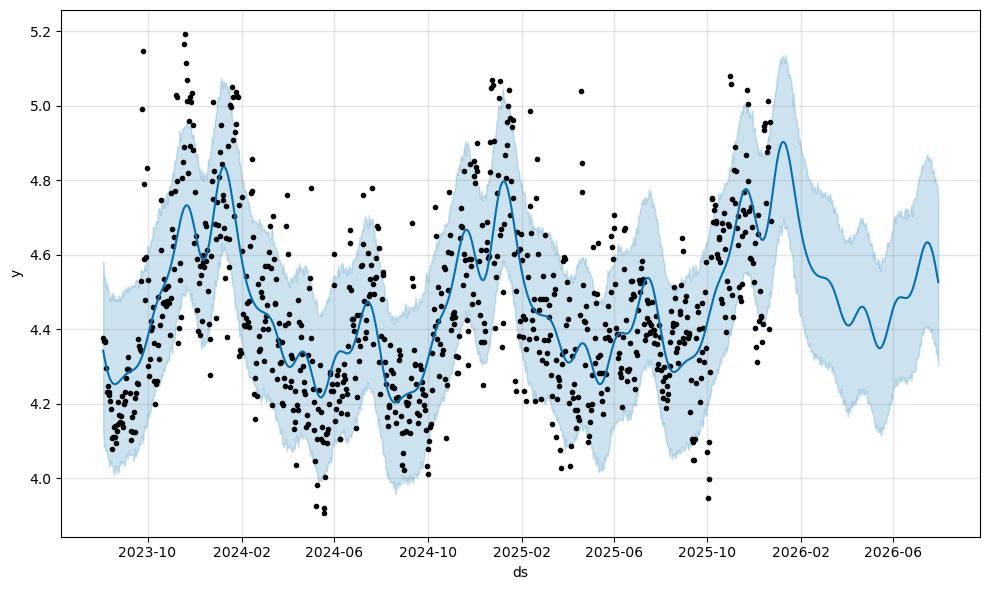

In [27]:
future_Data_Plot_Predict1 = model_simple.predict(future_Data_Plot)
model_simple.plot(future_Data_Plot_Predict1);

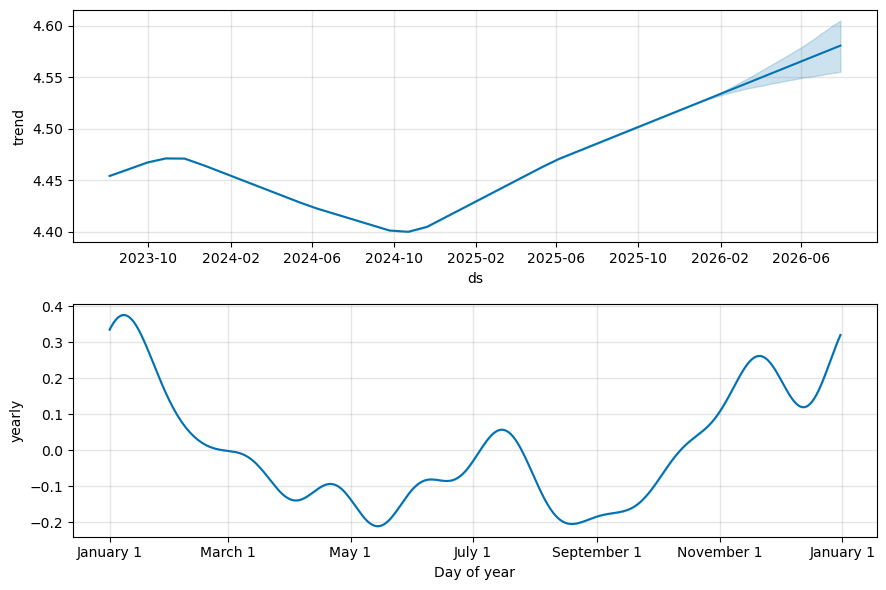

In [28]:
model_simple.plot_components(future_Data_Plot_Predict1);

# Inverse Transformation

In [29]:
future_Data_Plot_Backup = future_Data_Plot_Predict.copy()

In [30]:
future_Data_Plot_Backup["yhat"] = np.exp(future_Data_Plot_Backup["yhat"])
future_Data_Plot_Backup["yhat_lower"] = np.exp(future_Data_Plot_Backup["yhat_lower"])
future_Data_Plot_Backup["yhat_upper"] = np.exp(future_Data_Plot_Backup["yhat_upper"])

In [31]:
future_Data_Plot_Backup.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,rolled_mean_aqi_24hr,rolled_mean_aqi_24hr_lower,rolled_mean_aqi_24hr_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-08-04,4.492090,63.781327,93.412872,4.492090,4.492090,-0.143887,-0.143887,-0.143887,-0.180913,...,-0.053823,-0.053823,-0.053823,0.037026,0.037026,0.037026,0.0,0.0,0.0,77.339297
1,2023-08-05,4.492141,59.982287,86.561718,4.492141,4.492141,-0.217697,-0.217697,-0.217697,-0.249007,...,-0.030502,-0.030502,-0.030502,0.031310,0.031310,0.031310,0.0,0.0,0.0,71.840122
2,2023-08-06,4.492192,56.307852,82.333480,4.492192,4.492192,-0.270074,-0.270074,-0.270074,-0.295938,...,-0.051466,-0.051466,-0.051466,0.025864,0.025864,0.025864,0.0,0.0,0.0,68.177732
3,2023-08-07,4.492243,58.757953,85.531506,4.492243,4.492243,-0.237980,-0.237980,-0.237980,-0.258693,...,-0.053404,-0.053404,-0.053404,0.020713,0.020713,0.020713,0.0,0.0,0.0,70.404882
4,2023-08-08,4.492294,59.643561,86.958417,4.492294,4.492294,-0.221237,-0.221237,-0.221237,-0.237109,...,-0.042627,-0.042627,-0.042627,0.015872,0.015872,0.015872,0.0,0.0,0.0,71.597275


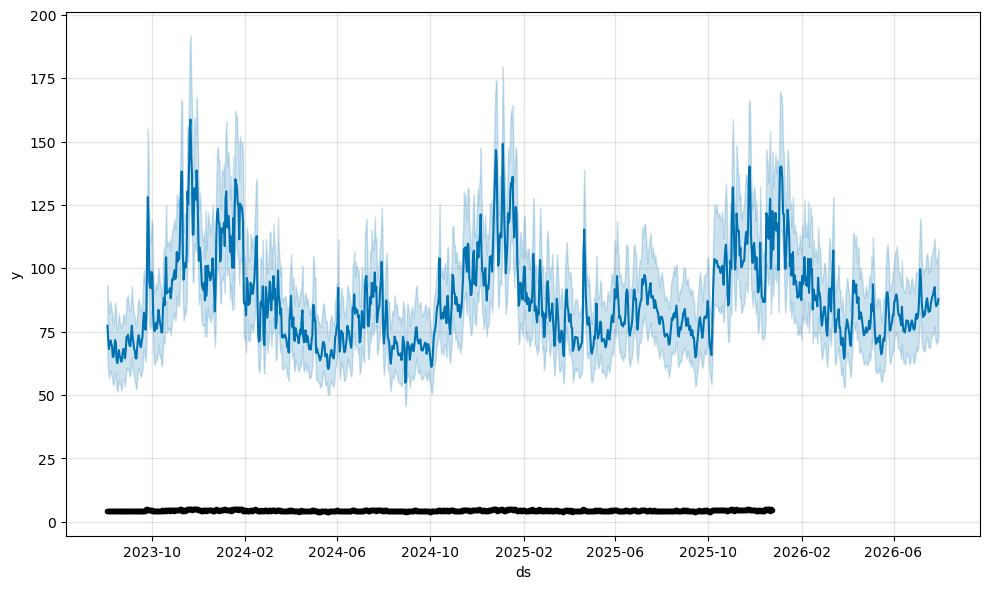

In [32]:
model.plot(future_Data_Plot_Backup);

# Inverse Transformation Of Without Regressor Model

In [33]:
future_Data_Plot_Backup1 = future_Data_Plot_Predict1.copy()

In [34]:
future_Data_Plot_Backup1["yhat"] = np.exp(future_Data_Plot_Backup1["yhat"])
future_Data_Plot_Backup1["yhat_lower"] = np.exp(future_Data_Plot_Backup1["yhat_lower"])
future_Data_Plot_Backup1["yhat_upper"] = np.exp(future_Data_Plot_Backup1["yhat_upper"])

In [35]:
future_Data_Plot_Backup1.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-08-04,4.454252,62.233474,97.849914,4.454252,4.454252,-0.112092,-0.112092,-0.112092,-0.112092,-0.112092,-0.112092,0.0,0.0,0.0,76.873392
1,2023-08-05,4.454484,59.340024,93.953621,4.454484,4.454484,-0.123502,-0.123502,-0.123502,-0.123502,-0.123502,-0.123502,0.0,0.0,0.0,76.018910
2,2023-08-06,4.454717,59.766830,93.816062,4.454717,4.454717,-0.134367,-0.134367,-0.134367,-0.134367,-0.134367,-0.134367,0.0,0.0,0.0,75.214922
3,2023-08-07,4.454949,58.715109,92.097101,4.454949,4.454949,-0.144603,-0.144603,-0.144603,-0.144603,-0.144603,-0.144603,0.0,0.0,0.0,74.466268
4,2023-08-08,4.455182,58.869714,90.987381,4.455182,4.455182,-0.154138,-0.154138,-0.154138,-0.154138,-0.154138,-0.154138,0.0,0.0,0.0,73.776754


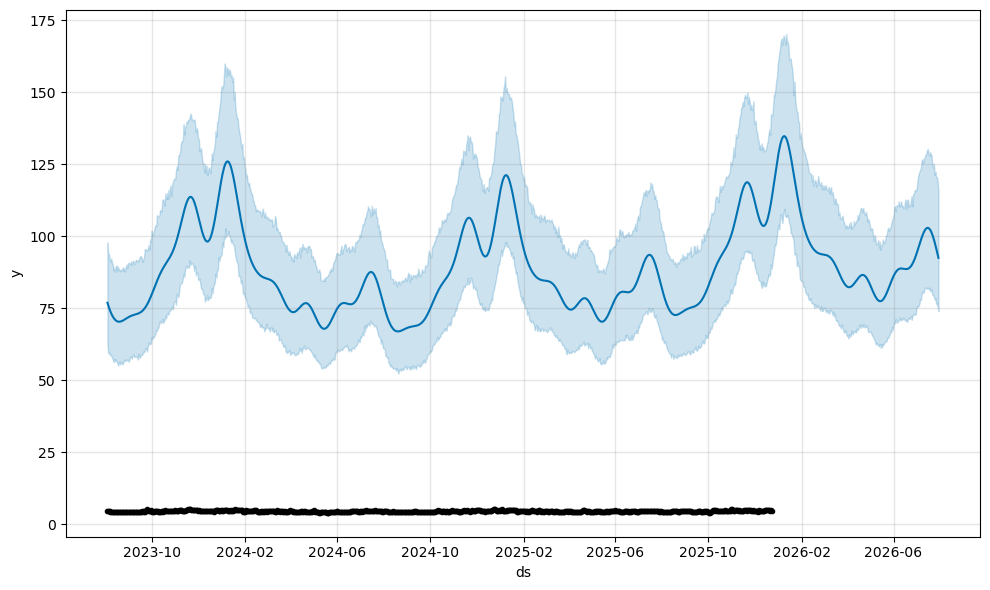

In [36]:
model_simple.plot(future_Data_Plot_Backup1);

# Evaluation 

In [37]:
forecast_test = model.predict(Test)
y_pred = np.exp(forecast_test["yhat"])
y_true = Test["y_orig"].values

print(f"R2 Score: {r2_score(y_true, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_true, y_pred)}")
print(f"Root Mean Square Error: {np.sqrt(mean_squared_error(y_true, y_pred))}")
print(f"Mean Square Error: {mean_squared_error(y_true, y_pred)}")

R2 Score: 0.5176375763298097
Mean Absolute Error: 9.824047091826632
Root Mean Square Error: 13.137637469800405
Mean Square Error: 172.59751828790357


# Simple Model Evaluation

In [40]:
forecast_test1 = model_simple.predict(Test)
y_pred1 = np.exp(forecast_test1["yhat"])
y_true1 = Test["y_orig"].values

print(f"R2 Score: {r2_score(y_true1, y_pred1)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_true1, y_pred1)}")
print(f"Root Mean Square Error: {np.sqrt(mean_squared_error(y_true1, y_pred1))}")
print(f"Mean Square Error: {mean_squared_error(y_true1, y_pred1)}")

R2 Score: 0.003195284636672846
Mean Absolute Error: 15.436571900332389
Root Mean Square Error: 18.88580847005932
Mean Square Error: 356.6737615677643


# Baseline Test

In [41]:
true = Test["y_orig"].values
persist = Test["us_aqi"].values

print(f"R2 Score: {r2_score(true, persist)}")

R2 Score: 0.5520268637872803


# Note: Prophet not working well on the data, tuning will not be effective too.